# TOBAC Data Aggregation & Segmentation

Purpose: 
- Load model output, apply TOBAC to Albedo-field, and save results
- Filter boundary touching objects and save results

Contents:
- Load ICON NetCDF output for all cases/domains
- Apply TOBAC feature detection and segmentation
    - Quick QC plots to check which segmentation-threshold works best
    - Compute and store 'Features_fields' and 'Mask_fields' with chosen segmentation-Thresholds (also computes and adds "size_km2" to 'Features_fields']
- Filter boundary ouching objects for each Case, Domain and timestamp
    - Store 'Mask_fields_filtered' and 'Features_fields_filtered'

Saves for each case and domain:
- /output_features/features_case?_DOM0?.csv
- /output_masks/mask_case?_DOM0?.nc
- /output_features/features_filt_case?_DOM0?.csv
- /output_masks/mask_filt_case?_DOM0?.nc

In [1]:
# system libs
import os, sys, glob
import datetime

import tobac
import xarray as xr    
import numpy as np
if not hasattr(np, "int"):   np.int = int   # use this for the np.int problem

import matplotlib.pyplot as plt

print("numpy:", np.__version__) #np.int which was removed in nuumpy version 2.x.x which is needed for convert_timevec tool (solution: downgraded np-version to <2 in the tobac env)
print("tobac:", tobac.__version__)

print("Python:", sys.executable)
assert "conda/envs/tobac" in sys.executable, "Not using the tobac kernel — switch to 'tobac (Levante)'."


# array operators and netcdf datasets
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)
import pandas as pd

# to have tools to format time
sys.path.append( '/work/bb1224/2024_MS-COURSE/tools/analysis' )
from tools import convert_timevec

import warnings
warnings.simplefilter("ignore")

numpy: 1.26.4
tobac: 1.6.1
Python: /work/bb1376/user/daniel/conda/envs/tobac/bin/python


## Tobac Segmenation

### Open Datasets, build fields[case][dom]

In [2]:
def load_icon_2d_radiation(sim_path, dom):
    """Load ICON 2D radiation dataset for a given simulation path & domain."""
    pattern = f"{sim_path}/2d_rad_{dom}_ML_????????T????00Z_regrid0005d.nc"
    ds = xr.open_mfdataset(pattern, combine="by_coords")
    return ds


def preprocess_dataset(ds, lat_min, lat_max, lon_min, lon_max):
    # convert time
    ds["time"] = convert_timevec(ds.time.data)

    # spatial selection
    ds = ds.sel(lat=slice(lat_min, lat_max),
                lon=slice(lon_min, lon_max))
    return ds


def compute_albedo_field(ds):
    """Compute ALBEDO = (sod_t - sob_t) / sod_t."""
    return (ds["sod_t"] - ds["sob_t"]) / ds["sod_t"]


# Case definitions: paths and domain IDs
cases = {
    "case1": "/work/bb1376/user/daniel/icon-build/experiments/cesar1-20240806-exp010",
    "case2": "/work/bb1376/user/daniel/icon-build/experiments/cesar2-20240928-exp010",
    #"case3": "/work/bb1376/user/daniel/icon-build/experiments/cesar3-20241110-exp010", # Case 3 not suitable because whole domain is cloud-covered 
}

domains = ["DOM01", "DOM02", "DOM03"]

# Lindenberg selection area
lat_min, lat_max = 51.85, 52.55
lon_min, lon_max = 13.65, 14.55


# MAIN LOOP: build fields[case][dom]
fields = {}   # final output dict

for case_name, sim_path in cases.items():
    print(f"\nProcessing {case_name} ...")
    
    fields[case_name] = {}

    for dom in domains:
        print(f"  Loading {dom} ...")

        # load dataset
        ds = load_icon_2d_radiation(sim_path, dom)

        # preprocess: format time + spatial crop
        ds = preprocess_dataset(ds, lat_min, lat_max, lon_min, lon_max)

        # compute field
        field = compute_albedo_field(ds)

        # store
        fields[case_name][dom] = field

print("\n✔ All cases/domains loaded into 'fields' dictionary!")




Processing case1 ...
  Loading DOM01 ...


sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


  Loading DOM02 ...
  Loading DOM03 ...

Processing case2 ...
  Loading DOM01 ...


sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


  Loading DOM02 ...
  Loading DOM03 ...


sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found



✔ All cases/domains loaded into 'fields' dictionary!


sh: getfattr: command not found


In [3]:
def get_spacings(field: xr.DataArray):
    """
    Compute horizontal grid spacing dxy [meters] and time step dt [seconds]
    from an field with coords (lat, lon, time).

    Parameters
    ----------
    field : xr.DataArray or xr.Dataset
        Must contain 'lat', 'lon', and optionally 'time'.

    Returns
    -------
    dxy : float
        Representative horizontal spacing [m] (geometric mean sqrt(dx*dy))
    dt  : float or None
        Median time step [s]; None if no time dimension exists.
    """

    field_cp = field.copy()

    # mean latitude to convert lon->meters
    lat0 = float(field_cp.lat.mean())

    # median step sizes in degrees
    dlat_deg = float(abs(field_cp.lat.diff("lat").median()))
    dlon_deg = float(abs(field_cp.lon.diff("lon").median()))

    # degrees -> meters (Earth-mean approximations)
    m_per_deg_lat = 110_574.0
    m_per_deg_lon = 111_320.0 * np.cos(np.deg2rad(lat0))

    # Convert to dx, dy in meters
    dy = dlat_deg * m_per_deg_lat
    dx = dlon_deg * m_per_deg_lon

    #  area-preserving geometric mean as representative spacing
    dxy = float(np.sqrt(dx * dy))

    #  Extract dt if time dimension exists
    if "time" in field_cp.coords:
        dt = float(
            (field_cp.time.diff("time") / np.timedelta64(1, "s"))
            .median()
            .item()
        )
    else:
        dt = None

    return dxy, dt


### Check for right segmentation threshold 


In [4]:
def compare_segmentation_thresholds(
    domain,
    case_name: str,
    dom_name: str,
    dxy: float,
    thresholds: list,
    parameters_features: dict,
    parameters_segmentation: dict,
    times_check: list,
):
    """
    Run TOBAC segmentation for multiple thresholds and plot comparison
    at selected times.

    Parameters
    ----------
    domain : xarray.DataArray
        Albedo field with time, lat, lon.
    case_name : str
    dom_name : str
    dxy : float
        Grid spacing [m].
    thresholds : list of float
        Segmentation thresholds to compare.
    parameters_features : dict
        Feature detection parameters.
    parameters_segmentation : dict
        Segmentation parameters (except 'threshold', which will be varied).
    times_check : list of str or np.datetime64
        Timestamps to visualize, will match nearest available.
    """

    times_all = domain.time.values
    times_plot = [np.datetime64(t) for t in times_check]
    n_rows = len(times_plot)
    n_cols = len(thresholds)

    fig, axs = plt.subplots(
        nrows=n_rows, ncols=n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        constrained_layout=True
    )
    fig.suptitle(f"{case_name} / {dom_name} — Segmentation Treshold Comparison", fontsize=16, fontweight="bold")

    # Run feature detection once
    Features = tobac.feature_detection_multithreshold(domain, dxy, **parameters_features)

    for i, t in enumerate(times_plot):
        idx = np.argmin(np.abs(times_all - t))
        t_near = times_all[idx]
        field_t = domain.isel(time=idx)

        for j, thresh in enumerate(thresholds):
            # Update segmentation threshold
            seg_params = parameters_segmentation.copy()
            seg_params["threshold"] = thresh

            # Segment
            mask, _ = tobac.segmentation_2D(Features, domain, dxy, **seg_params)
            mask_t = mask.isel(time=idx)

            # Plot
            ax = axs[i, j] if n_rows > 1 else axs[j]
            field_t.plot(ax=ax, cmap="binary", add_colorbar=False)
            mask_t.where(mask_t > 0).plot(ax=ax, cmap="tab20", alpha=0.6, add_colorbar=False)

            ax.set_title(f"{np.datetime_as_string(t_near, 'm')} — thresh={thresh}")

    plt.show()


In [5]:
# Dictionary containing keyword arguments for feature detection step .
parameters_features={}
parameters_features['position_threshold']='weighted_diff'
parameters_features['sigma_threshold']=0.5
parameters_features['n_min_threshold']=4
#parameters_features['target']='minimum'
parameters_features['target']='maximum'
parameters_features['threshold']=[0.9 ,0.7, 0.5, 0.3, 0.1]

# Dictionary containing keyword options for the segmentation step:
parameters_segmentation={}
#parameters_segmentation['target']='minimum'
parameters_segmentation['target']='maximum'
parameters_segmentation['method']='watershed'
#parameters_segmentation['threshold']= 0.5
parameters_segmentation['threshold']= 0.4


In [6]:
# Dictionary containing keyword arguments for feature detection step .
parameters_features={}
parameters_features['position_threshold']='weighted_diff'
parameters_features['sigma_threshold']=0.5
parameters_features['n_min_threshold']=4
#parameters_features['target']='minimum'
parameters_features['target']='maximum'
parameters_features['threshold']=[0.9 ,0.7, 0.5, 0.3, 0.1]

# Dictionary containing keyword options for the segmentation step:
parameters_segmentation={}
#parameters_segmentation['target']='minimum'
parameters_segmentation['target']='maximum'
parameters_segmentation['method']='watershed'
#parameters_segmentation['threshold']= 0.3
#parameters_segmentation['threshold']= 0.4

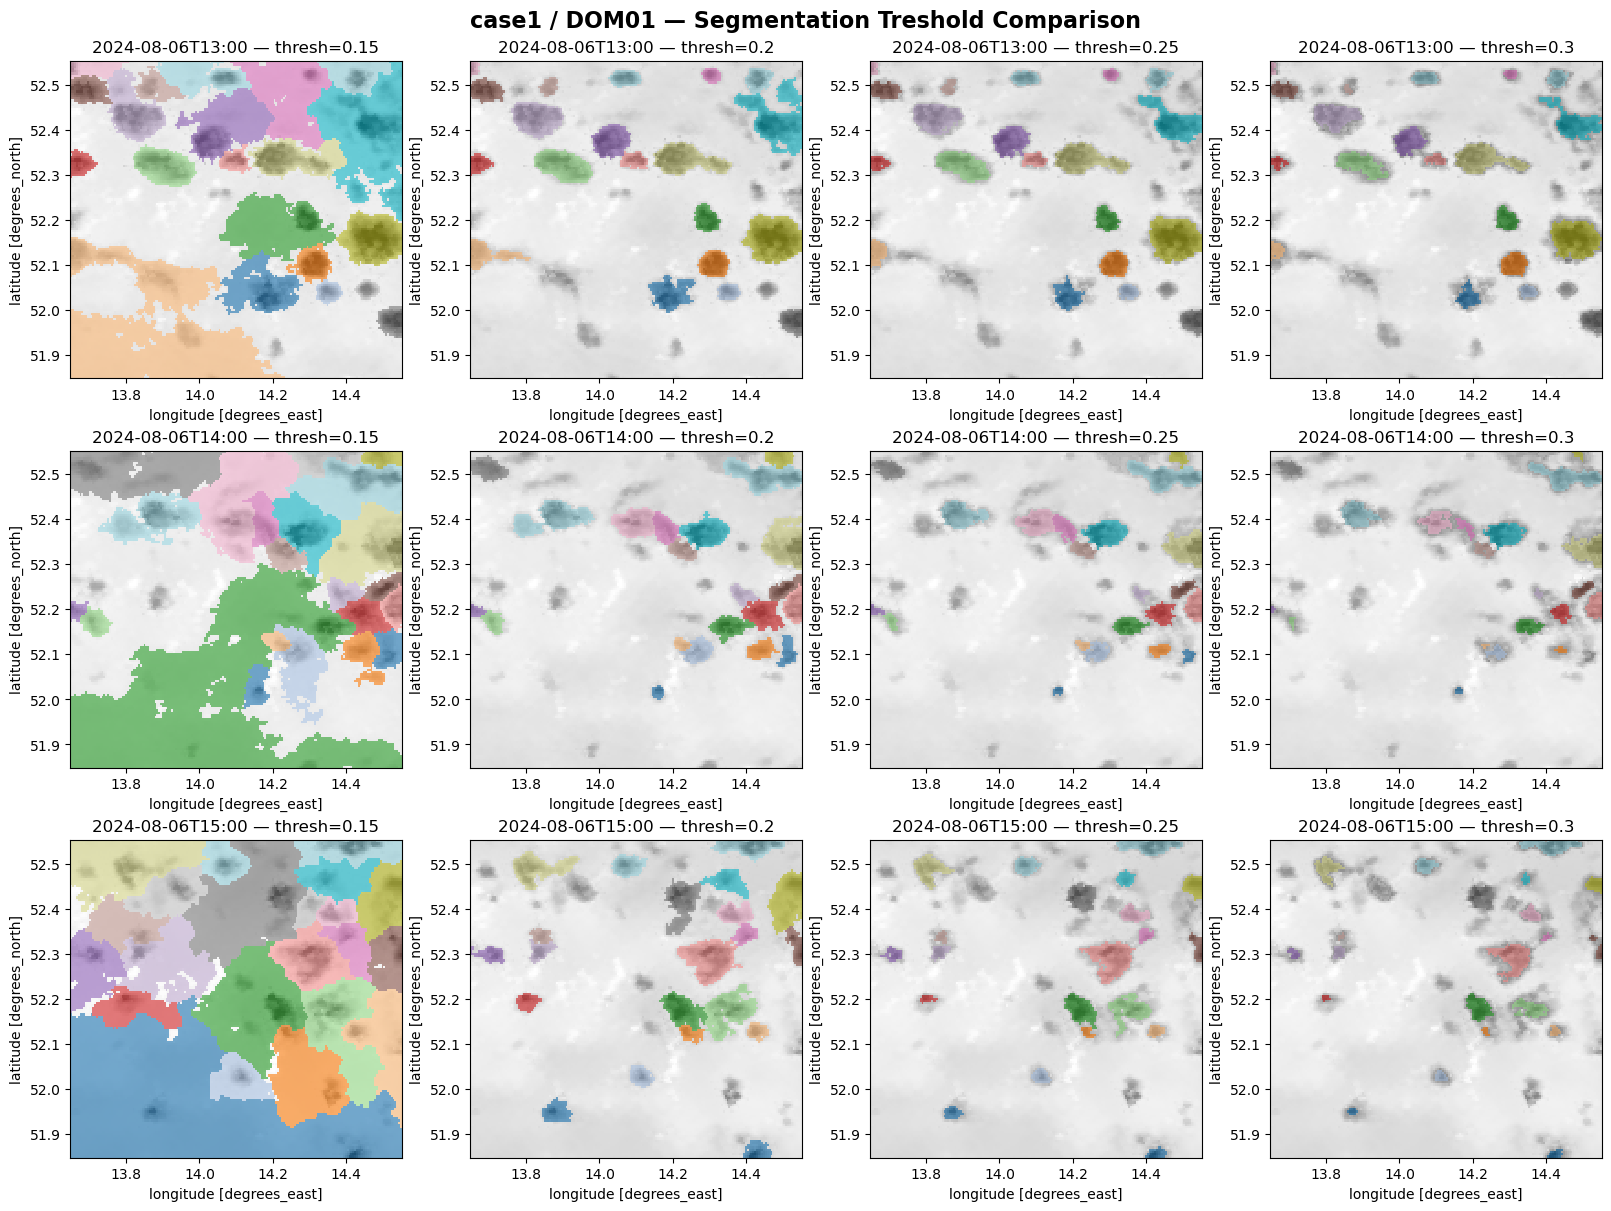

In [7]:
#case1
compare_segmentation_thresholds(
    domain       = fields["case1"]["DOM01"],
    case_name    = "case1",
    dom_name     = "DOM01",
    dxy          = get_spacings(fields["case1"]["DOM01"])[0],
    thresholds   = [0.15, 0.2, 0.25, 0.3],
    parameters_features     = parameters_features,
    parameters_segmentation = parameters_segmentation,
    times_check  = ["2024-08-06T13:00", "2024-08-06T14:00", "2024-08-06T15:00"],
)


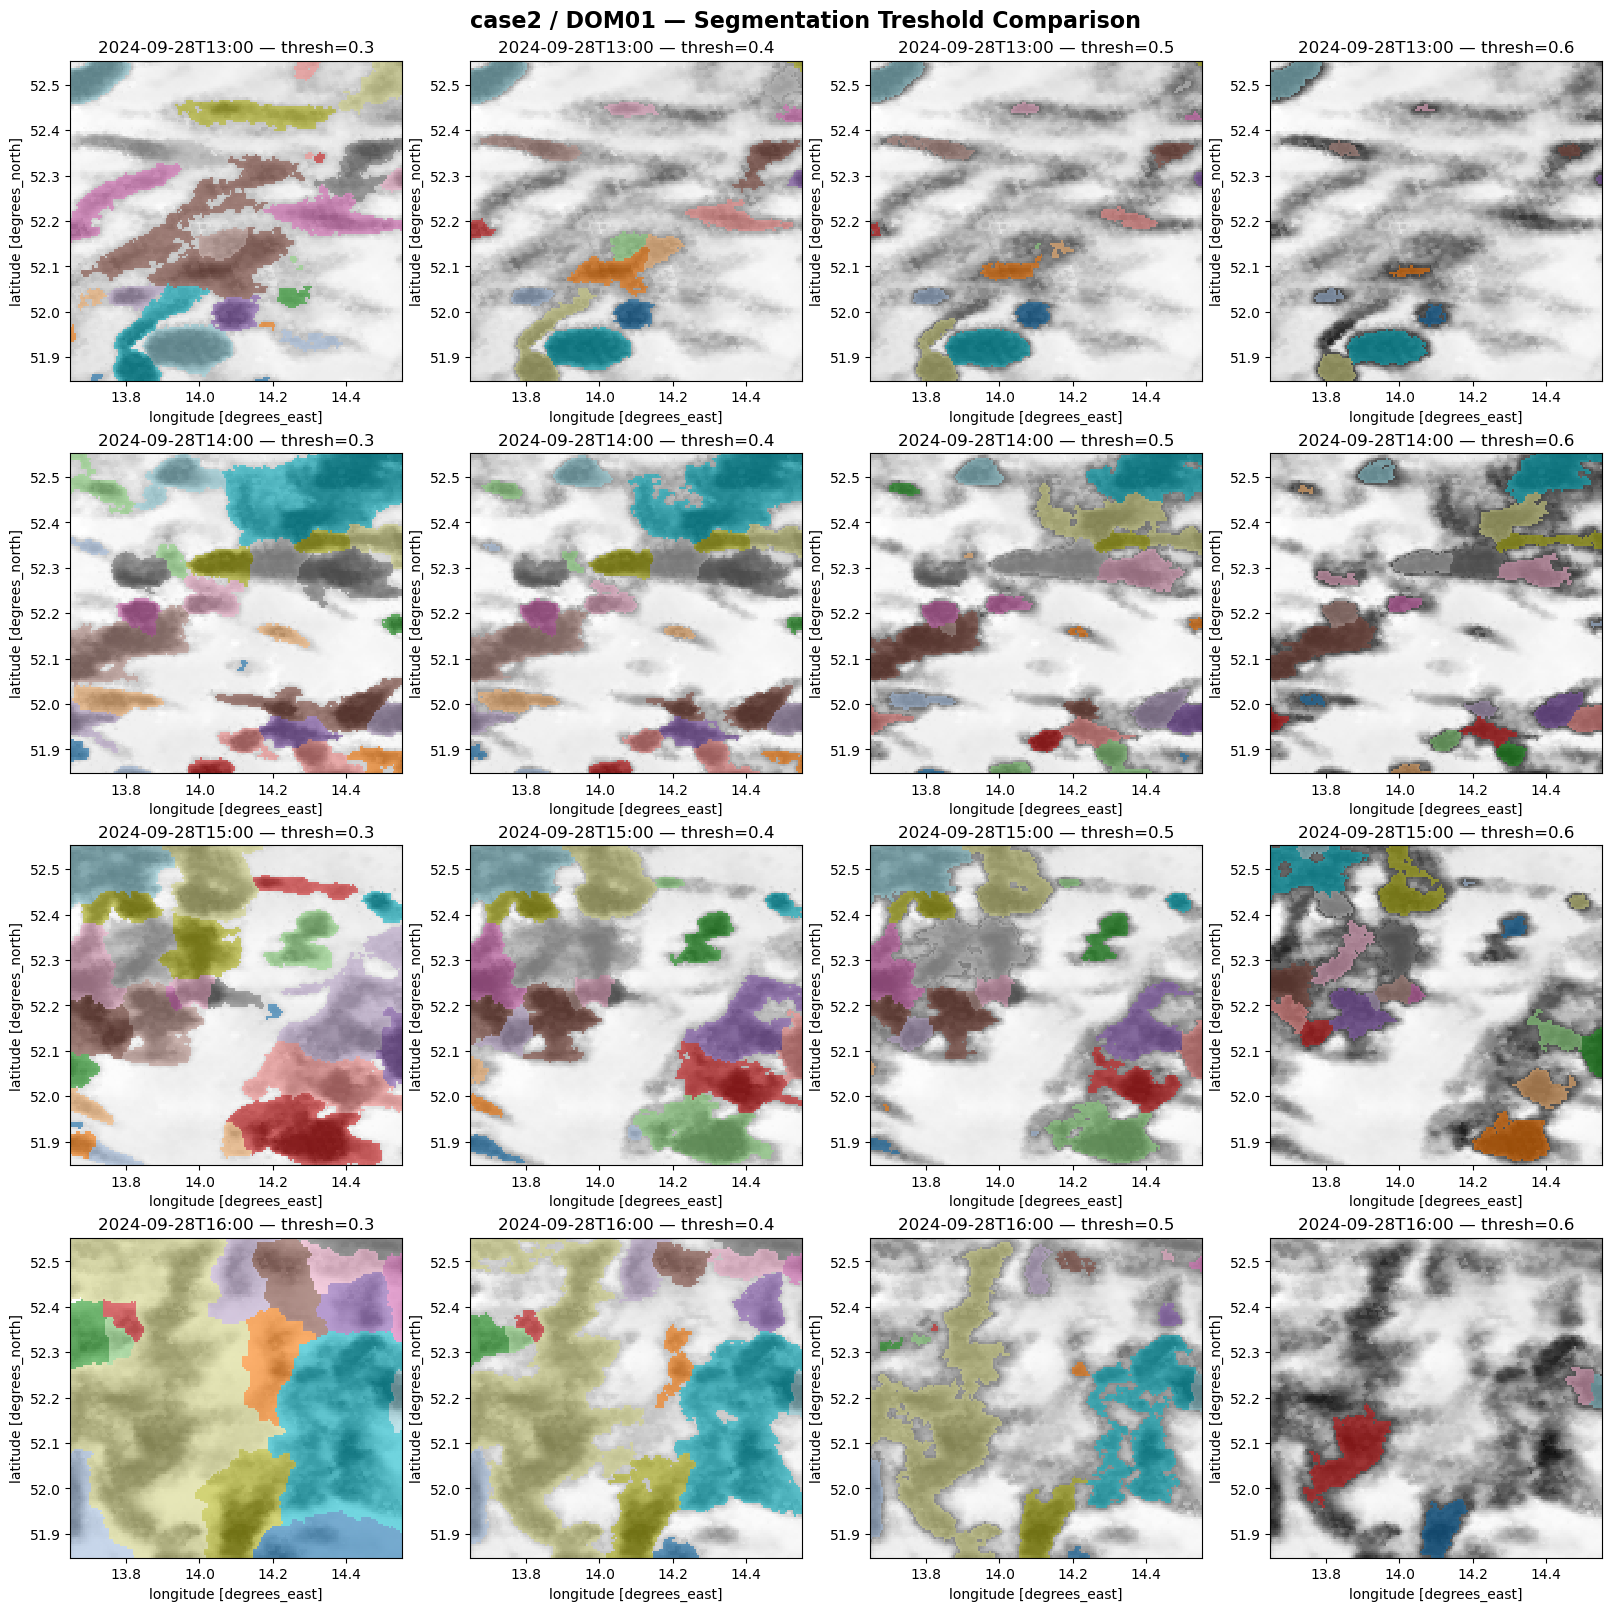

In [8]:
#case2
compare_segmentation_thresholds(
    domain       = fields["case2"]["DOM01"],
    case_name    = "case2",
    dom_name     = "DOM01",
    dxy          = get_spacings(fields["case2"]["DOM01"])[0],
    thresholds   = [0.3, 0.4, 0.5, 0.6],
    parameters_features     = parameters_features,
    parameters_segmentation = parameters_segmentation,
    times_check  = ["2024-09-28T13:00","2024-09-28T14:00", "2024-09-28T15:00", "2024-09-28T16:00"],
)

### Feature detection & segmentation with choosen threshold 

In [9]:
def run_tobac_for_domain(
    domain, 
    case_name: str, 
    dom_name: str, 
    dxy: float, 
    parameters_features: dict, 
    parameters_segmentation: dict,
):
    """
    Run TOBAC feature detection + segmentation for one domain field.

    Returns:
    - Features_field : pandas.DataFrame
        With extra columns: case, domain, size_km2.
    - Mask_field : xarray.DataArray
        Segmentation mask (time, lat, lon).
    """


    # 1) Feature detection + segmentation
    Features = tobac.feature_detection_multithreshold(
        domain, dxy, **parameters_features
    )

    Mask_field, Features_field = tobac.segmentation_2D(
        Features, domain, dxy, **parameters_segmentation
    )

    # 2) Add metadata
    Features_field["case"]   = case_name
    Features_field["domain"] = dom_name
    Features_field["size_km2"] = Features_field["ncells"] * (dxy**2) / 1e6

    return Features_field, Mask_field


In [10]:
# Define per-case/domain segmentation thresholds
segmentation_thresholds = {
    "case1": {"DOM01": 0.25, "DOM02": 0.25, "DOM03": 0.25},
    "case2": {"DOM01": 0.4, "DOM02": 0.4, "DOM03": 0.4},
}

# Dictionaries to store results
Features_fields = {}  # nested dict: Features_fields[case][dom]
Mask_fields = {}      # nested dict: Mask_fields[case][dom]

# Loop through all combinations
for case_name in ["case1", "case2"]:
    Features_fields[case_name] = {}
    Mask_fields[case_name] = {}

    for dom_name in ["DOM01", "DOM02", "DOM03"]:
        print(f"\n>>> Processing {case_name} / {dom_name}")

        domain = fields[case_name][dom_name]
        dxy, dt = get_spacings(domain)

        # Set segmentation threshold for this case/domain
        parameters_segmentation["threshold"] = segmentation_thresholds[case_name][dom_name]

        # Run TOBAC
        Features_field, Mask_field = run_tobac_for_domain(
            domain=domain,
            case_name=case_name,
            dom_name=dom_name,
            dxy=dxy,
            parameters_features=parameters_features,
            parameters_segmentation=parameters_segmentation,
        )

        # Store results
        Features_fields[case_name][dom_name] = Features_field
        Mask_fields[case_name][dom_name] = Mask_field

print("Done: Features_fields and Mask_fields created with custom thresholds.")


>>> Processing case1 / DOM01

>>> Processing case1 / DOM02

>>> Processing case1 / DOM03

>>> Processing case2 / DOM01

>>> Processing case2 / DOM02

>>> Processing case2 / DOM03
Done: Features_fields and Mask_fields created with custom thresholds.


### Quality Controll: Plot domain-comparison of segmatiation

In [11]:
def plot_domain_comparison_at_time(
    case_name: str,
    time_sel,
    fields: dict,
    Mask_fields: dict,
    dom_names = ("DOM01", "DOM02", "DOM03"),
):
    """
    Make comparison plots for several domains at one selected timestamp.

    Parameters
    ----------
    case_name : str
        e.g. "case1"
    time_sel : str or np.datetime64 or pandas.Timestamp
        Desired timestamp, e.g. "2024-09-28T14:00:00".
        Nearest available time per domain will be used.
    fields : dict
        fields[case][dom] -> xarray.DataArray with albedo field.
    Mask_fields : dict
        Mask_fields[case][dom] -> segmentation mask (time, lat, lon).
    features_catalog : pd.DataFrame
        Global feature catalog with columns 'case', 'domain', 'time', 'size_km2'.
    dom_names : iterable of str
        Domains to compare.
    """

    # ensure time_sel is np.datetime64[ns]
    time_sel = np.datetime64(time_sel)

    n_dom = len(dom_names)
    fig, axs = plt.subplots(
        nrows=n_dom, 
        ncols=1,
        figsize=(7, n_dom*4),
        constrained_layout=True
    )
    fig.suptitle(
        f"{case_name} — comparison at {time_sel.astype('datetime64[m]')}",
        fontsize=14, fontweight="bold"
    )

    if n_dom == 1:
        axs = np.array([axs])

    for i, dom in enumerate(dom_names):
        # -------------------------------
        # 1) select nearest time in this domain
        # -------------------------------
        field_dom = fields[case_name][dom]
        mask_dom  = Mask_fields[case_name][dom]

        times_dom = field_dom.time.values
        # index of nearest time
        idx = np.argmin(np.abs(times_dom - time_sel))
        t_dom = times_dom[idx]

        # field & mask at that time
        field_t = field_dom.isel(time=idx)
        mask_t  = mask_dom.isel(time=idx)


        # -------------------------------
        # 2) PLOTS
        # -------------------------------
        # field + segmentation
        field_t.plot(ax=axs[i], cmap="binary",cbar_kwargs={"label": "Albedo"})
        mask_t.where(mask_t > 0).plot(ax=axs[i], cmap="tab20", alpha=0.75)
        #mask_t.plot.contour(ax=axs[i], levels=np.unique(mask_t), colors='red', linewidths=0.5)    
        axs[i].set_title(f"{dom} — {np.datetime_as_string(t_dom, unit='m')}")



    plt.show()


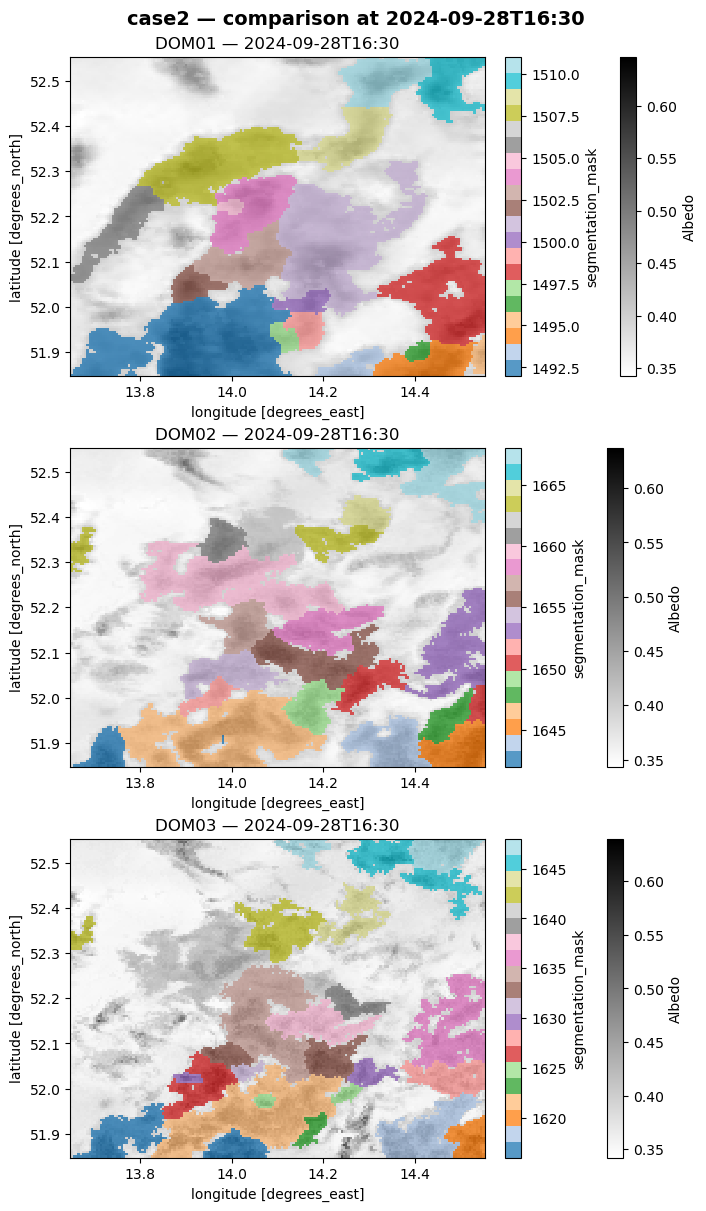

In [12]:
plot_domain_comparison_at_time(
    case_name        = "case2",
    time_sel         = "2024-09-28T16:30:00",
    fields           = fields,
    Mask_fields      = Mask_fields,
    dom_names        = ["DOM01", "DOM02", "DOM03"],
)

### Safe for later use


In [13]:
# Create a folder for output
#os.makedirs("output_masks", exist_ok=True)

#for case, domains in Mask_fields.items():
#    for dom, mask in domains.items():
#        filename = f"output_masks/mask_{case}_{dom}.nc"
#        mask.to_netcdf(filename)


sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found


In [14]:
# Create a folder
#os.makedirs("output_features", exist_ok=True)

#for case, domains in Features_fields.items():
#    for dom, df in domains.items():
#        filename = f"output_features/features_{case}_{dom}.csv"
#        df.to_csv(filename, index=False)

## Filtering Boundary-Touching Objects

In [15]:
def filter_boundary_objects(mask, features, verbose=False):
    """
    Remove objects touching the spatial boundary from both mask and feature catalog.
    
    Parameters
    ----------
    mask : xarray.DataArray
        TOBAC segmentation mask (time, lat, lon)
    features : pd.DataFrame
        Features_field dataframe with columns ['feature', 'time']
    
    Returns
    -------
    mask_filtered : xarray.DataArray
    features_filtered : pd.DataFrame
    """
    mask_filtered = mask.copy(deep=True)
    keep_mask = np.ones_like(mask_filtered, dtype=bool)

    features_filtered = features.copy()
    remove_ids = []

    for i, t in enumerate(mask.time.values):
        mask_t = mask.isel(time=i)

        lat0, lat1 = 0, mask.sizes['lat'] - 1
        lon0, lon1 = 0, mask.sizes['lon'] - 1

        edges = [
            mask_t.isel(lat=lat0),
            mask_t.isel(lat=lat1),
            mask_t.isel(lon=lon0),
            mask_t.isel(lon=lon1),
        ]

        boundary_labels = set()
        for edge in edges:
            edge_vals = edge.values
            labels = np.unique(edge_vals)
            boundary_labels.update(labels[labels > 0])

        if verbose:
            print(f"[{t}] Removing {len(boundary_labels)} labels")

        # Set those object labels to 0 (background)
        for label in boundary_labels:
            mask_filtered[i] = mask_filtered[i].where(mask_filtered[i] != label)

        # Drop from features
        t_mask = (features_filtered["time"] == t)
        f_ids = features_filtered.loc[t_mask, "feature"]
        drop_ids = f_ids[f_ids.isin(boundary_labels)].index
        remove_ids.extend(drop_ids)

    features_filtered = features_filtered.drop(remove_ids)

    return mask_filtered, features_filtered


In [16]:
# Initialize nested dictionaries
Mask_fields_filtered = {}
Features_fields_filtered = {}

# Loop over all cases and domains
for case_name in Features_fields:
    Mask_fields_filtered[case_name] = {}
    Features_fields_filtered[case_name] = {}

    for dom_name in Features_fields[case_name]:
        print(f"Filtering boundary-touching objects for {case_name} / {dom_name} ...")

        mask     = Mask_fields[case_name][dom_name]
        features = Features_fields[case_name][dom_name]

        mask_filt, features_filt = filter_boundary_objects(
            mask, features, verbose=True
        )

        # Store filtered results
        Mask_fields_filtered[case_name][dom_name]     = mask_filt
        Features_fields_filtered[case_name][dom_name] = features_filt


Filtering boundary-touching objects for case1 / DOM01 ...
[2024-08-06T12:00:00.000000000] Removing 6 labels
[2024-08-06T12:05:00.000000000] Removing 6 labels
[2024-08-06T12:10:00.000000000] Removing 4 labels
[2024-08-06T12:15:00.000000000] Removing 6 labels
[2024-08-06T12:20:00.000000000] Removing 7 labels
[2024-08-06T12:25:00.000000000] Removing 8 labels
[2024-08-06T12:30:00.000000000] Removing 5 labels
[2024-08-06T12:35:00.000000000] Removing 3 labels
[2024-08-06T12:40:00.000000000] Removing 5 labels
[2024-08-06T12:45:00.000000000] Removing 6 labels
[2024-08-06T12:50:00.000000000] Removing 9 labels
[2024-08-06T12:55:00.000000000] Removing 8 labels
[2024-08-06T13:00:00.000000000] Removing 7 labels
[2024-08-06T13:05:00.000000000] Removing 7 labels
[2024-08-06T13:10:00.000000000] Removing 8 labels
[2024-08-06T13:15:00.000000000] Removing 8 labels
[2024-08-06T13:20:00.000000000] Removing 9 labels
[2024-08-06T13:25:00.000000000] Removing 10 labels
[2024-08-06T13:30:00.000000000] Removing 

### QC Plot

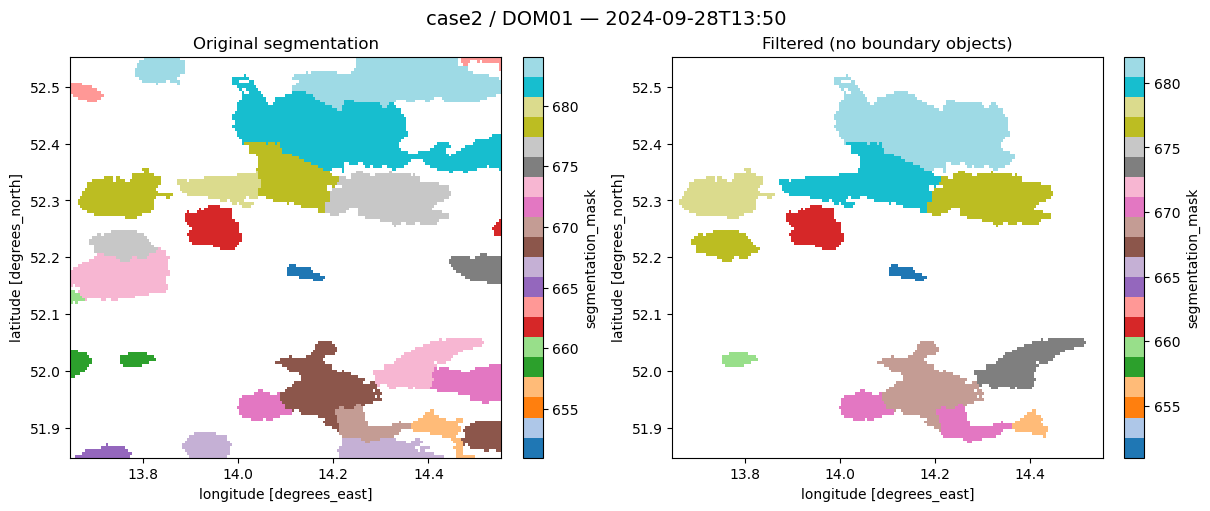

In [17]:
"""
Compare original and filtered TOBAC segmentation masks side-by-side
for a single domain and timestamp.
"""
case_name = "case2"
dom_name = "DOM01"

time_sel = "2024-09-28T13:50:00"
time_sel = np.datetime64(time_sel)

#mask_orig = Mask_fields[case_name][dom_name]
#mask_filt = Mask_fields_filtered[case_name][dom_name]
mask_orig = Mask_fields[case_name][dom_name]
mask_filt = Mask_fields_filtered[case_name][dom_name]


# get nearest available time index
times = mask_orig.time.values
idx = np.argmin(np.abs(times - time_sel))
t_near = times[idx]


mask_orig_t = mask_orig.isel(time=idx)
mask_filt_t = mask_filt.isel(time=idx)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle(f"{case_name} / {dom_name} — {np.datetime_as_string(t_near, unit='m')}", fontsize=14)

# Original mask
mask_orig_t.where(mask_orig_t > 0).plot(ax=axs[0], cmap="tab20")
axs[0].set_title("Original segmentation")

# Filtered mask
mask_filt_t.where(mask_filt_t > 0).plot(ax=axs[1], cmap="tab20")
axs[1].set_title("Filtered (no boundary objects)")

plt.show()

### Safe for later use

In [18]:
# Create a folder for output
#os.makedirs("output_masks", exist_ok=True)
#
#for case, domains in Mask_fields_filtered.items():
#    for dom, mask in domains.items():
#        filename = f"output_masks/mask_filt_{case}_{dom}.nc"
#        mask.to_netcdf(filename)

# Create a folder
#os.makedirs("output_features", exist_ok=True)

#for case, domains in Features_fields_filtered.items():
#    for dom, df in domains.items():
#        filename = f"output_features/features_filt_{case}_{dom}.csv"
#        df.to_csv(filename, index=False)


sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
sh: getfattr: command not found
